# Architecture, temporal settings and model selection

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Rectangle
from scipy.stats import wilcoxon

from attention_lapse_detection.training.selection import CELL, select, selection_table
from attention_lapse_detection.utils.constants import FPS_OPTIONS, SEED
from attention_lapse_detection.utils.paths import PATHS
from attention_lapse_detection.training.data import load_clean_split
from attention_lapse_detection.training.report import mean_sd

MODEL_NAMES = {
    "gru": "GRU",
    "lstm": "LSTM",
    "gru_uni_attention": "GRU + attention",
    "lstm_uni_attention": "LSTM + attention",
}

In [10]:
all_runs = pd.read_csv(PATHS.experiments / "results/thesis_runs.csv")

full_feature_runs = all_runs[all_runs.features == "all_features"]

seed_records = full_feature_runs.sort_values(CELL + ["seed"])
seed_records.to_csv(
    PATHS.experiments / "appendix_validation_seed_records.csv", index=False
)

scores = full_feature_runs.pivot(index="seed", columns=CELL, values="val_clip_ap")
shortlist = selection_table(full_feature_runs)
cells = shortlist[["val_ap", "sd", "params"]]

LARGEST = cells.val_ap.idxmax()
RETAINED = select(full_feature_runs)
m, f, w = RETAINED

_, val_y = load_clean_split(f, [], "Validation", w)
chance_ap = (val_y == 0).mean()

print(
    f"{len(full_feature_runs)} runs, {len(cells)} configurations, seeds {list(scores.index)}, chance AP {chance_ap:.4f}"
)

192 runs, 24 configurations, seeds [42, 43, 44, 52, 53, 54, 55, 56], chance AP 0.1162


## Figure 6.1 Full validation comparison


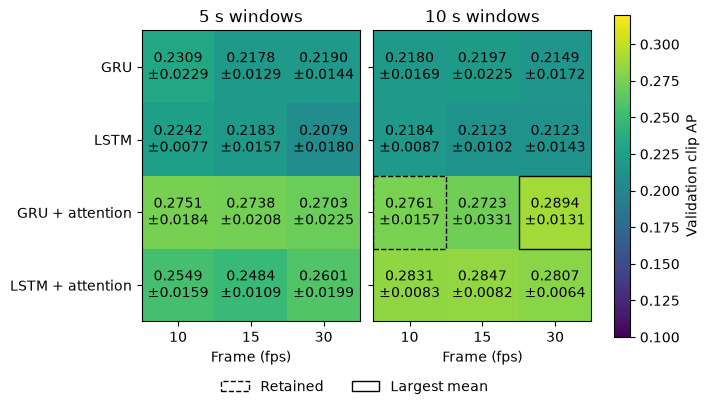

In [36]:
MODELS = list(MODEL_NAMES)

borders = {LARGEST: ("-", "Largest mean"), RETAINED: ("--", "Retained")}

fps_list = list(FPS_OPTIONS)
ap_grid = cells.val_ap.unstack("fps").reindex(columns=fps_list)
sd_grid = cells.sd.unstack("fps").reindex(columns=fps_list)

fig, axes = plt.subplots(1, 2, figsize=(7, 4), sharey=True, layout="constrained")

for ax, window in zip(axes, (5, 10)):
    ap = ap_grid.xs(window, level="window_seconds").reindex(MODELS).to_numpy()
    sd = sd_grid.xs(window, level="window_seconds").reindex(MODELS).to_numpy()

    ax.imshow(ap, vmin=0.10, vmax=0.32)

    for row, model in enumerate(MODELS):
        for col, fps in enumerate(fps_list):
            ax.text(
                col,
                row,
                mean_sd(ap[row, col], sd[row, col]).replace(" ± ", "\n±"),
                ha="center",
                va="center",
            )

            if (model, fps, window) in borders:
                style, label = borders[model, fps, window]
                ax.add_patch(
                    Rectangle(
                        (col - 0.5, row - 0.5),
                        1,
                        1,
                        fill=False,
                        edgecolor="k",
                        ls=style,
                        label=label,
                    )
                )

    ax.set_xticks(range(len(fps_list)), fps_list)
    ax.set_yticks(range(len(MODELS)), [MODEL_NAMES[m] for m in MODELS])
    ax.set(xlabel="Frame (fps)", title=f"{window} s windows")

fig.colorbar(axes[0].images[0], ax=axes, label="Validation clip AP")
fig.legend(loc="outside lower center", ncol=2, frameon=False)

plt.show()

In [37]:
pd.Series(
    [mean_sd(m, s) for m, s in zip(cells.val_ap, cells.sd)], index=cells.index
).unstack("fps")


fps                                             10               15  \
model              window_seconds                                     
gru                5               0.2309 ± 0.0229  0.2178 ± 0.0129   
                   10              0.2180 ± 0.0169  0.2197 ± 0.0225   
gru_uni_attention  5               0.2751 ± 0.0184  0.2738 ± 0.0208   
                   10              0.2761 ± 0.0157  0.2723 ± 0.0331   
lstm               5               0.2242 ± 0.0077  0.2183 ± 0.0157   
                   10              0.2184 ± 0.0087  0.2123 ± 0.0102   
lstm_uni_attention 5               0.2549 ± 0.0159  0.2484 ± 0.0109   
                   10              0.2831 ± 0.0083  0.2847 ± 0.0082   

fps                                             30  
model              window_seconds                   
gru                5               0.2190 ± 0.0144  
                   10              0.2149 ± 0.0172  
gru_uni_attention  5               0.2703 ± 0.0225  
                   10              0.2894 ± 0.0131  
lstm               5               0.2079 ± 0.0180  
                   10              0.2123 ± 0.0143  
lstm_uni_attention 5               0.2601 ± 0.0199  
                   10              0.2807 ± 0.0064

## Figure 6.2 Average effects of temporal settings

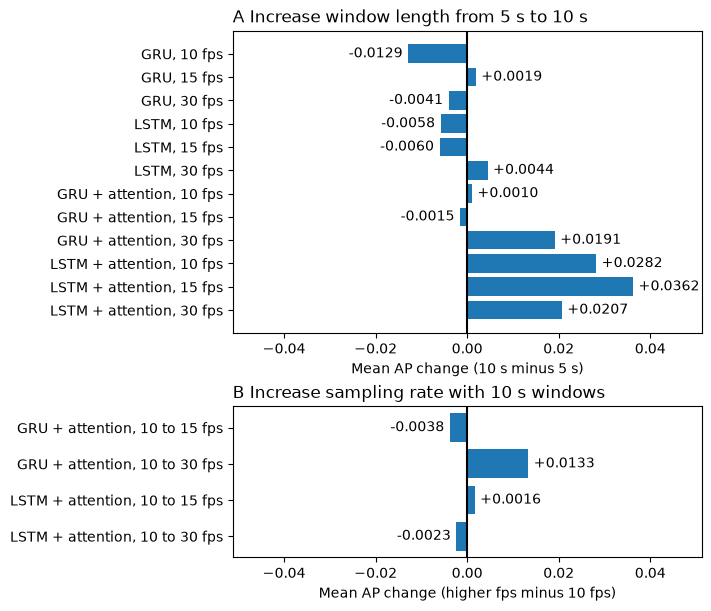

In [56]:
window_pairs = [
    (f"{MODEL_NAMES[m]}, {f} fps", (m, f, 10), (m, f, 5))
    for m in MODELS
    for f in FPS_OPTIONS
]

fps_pairs = [
    (f"{MODEL_NAMES[m]}, 10 to {f} fps", (m, f, 10), (m, 10, 10))
    for m in ("gru_uni_attention", "lstm_uni_attention")
    for f in (15, 30)
]

window_differences = pd.DataFrame(
    {label: scores[a] - scores[b] for label, a, b in window_pairs}
)

fps_differences = pd.DataFrame(
    {label: scores[a] - scores[b] for label, a, b in fps_pairs}
)

limit = (
    max(window_differences.mean().abs().max(), fps_differences.mean().abs().max())
    + 0.015
)


def mean_bars(ax, means, title, xlabel):
    ax.barh(means.index, means)
    
    for row, value in enumerate(means):
        ax.annotate(
            f"{value:+.4f}",
            (value, row),
            xytext=(4 if value >= 0 else -4, 0),
            textcoords="offset points",
            ha="left" if value >= 0 else "right",
            va="center",
        )
        
    ax.axvline( color="k",)
    ax.invert_yaxis()
    
    ax.set(xlim=(-limit, limit), xlabel=xlabel)
    ax.set_title(title, loc="left")


fig, axes = plt.subplots(
    2,
    1,
    figsize=(7, 6),
    gridspec_kw={"height_ratios": [3, 1.5]},
    layout="constrained",
)

mean_bars(
    axes[0],
    window_differences.mean(),
    "A Increase window length from 5 s to 10 s",
    "Mean AP change (10 s minus 5 s)",
)
mean_bars(
    axes[1],
    fps_differences.mean(),
    "B Increase sampling rate with 10 s windows",
    "Mean AP change (higher fps minus 10 fps)",
)

plt.show()

## Table 6.2 Retained configuration and highest-mean reference

In [59]:
is_deliverable = (
    (full_feature_runs.model == m)
    & (full_feature_runs.fps == f)
    & (full_feature_runs.window_seconds == w)
    & (full_feature_runs.seed == SEED)
)

DELIVERABLE = full_feature_runs[is_deliverable].iloc[0]

eligible_count = shortlist.eligible.sum()
retained_params = cells.params[RETAINED]

print(
    f"{eligible_count} of {len(shortlist)} configurations eligible, "
    f"fewest parameters: {RETAINED}, {retained_params:,} parameters"
)

print(
    f"Selected checkpoint: {DELIVERABLE.checkpoint} "
    f"(val clip AP {DELIVERABLE.val_clip_ap:.4f}, threshold {DELIVERABLE.threshold:.4f})"
)

print(
    f"Model settings: {DELIVERABLE.hidden_size} units, {DELIVERABLE.num_layers} layers, "
    f"dropout {DELIVERABLE.dropout:.2f}, learning rate {DELIVERABLE.learning_rate:.2e}, batch {DELIVERABLE.batch_size}"
)

comparison = shortlist.loc[[RETAINED, LARGEST]]

pd.DataFrame(
    {
        "Role": ["Retained", "Highest-mean reference"],
        "Configuration": [
            f"{MODEL_NAMES[model]}, {fps}fps / {window}s"
            for model, fps, window in comparison.index
        ],
        "AP ± SD": [mean_sd(m, s) for m, s in zip(comparison.val_ap, comparison.sd)],
        "Parameters": comparison.params.astype(int).to_numpy(),
    }
)

9 of 24 configurations eligible, fewest parameters: ('gru_uni_attention', 10, 10), 115,083 parameters
Selected checkpoint: gru_uni_attention_10fps_10s_all_features_s42 (val clip AP 0.2836, threshold 0.4651)
Model settings: 105 units, 2 layers, dropout 0.05, learning rate 5.34e-04, batch 64


,Role,Configuration,AP ± SD,Parameters
0,Retained,"GRU + attention, 10fps / 10s",0.2761 ± 0.0157,115083
1,Highest-mean reference,"GRU + attention, 30fps / 10s",0.2894 ± 0.0131,650403


## Supporting: learning curve of the retained checkpoint (appendix)

Epoch history for the 10s, seed 42 run, taken from `logs/expreiments_gru_uni_attention_10fps.log` (all 16 runs at 10fps: 5s seeds first, then 10s seeds). Retained weights are from the best validation AP epoch; training stopped after four epochs without improvement. Vertical lines indicate the retained epoch (dotted) and stopping epoch (dashed); the AP reference is validation prevalence. 

best epoch 7 (stored 7), val AP 0.2836 (stored 0.2836); stopped after epoch 11 (stored 11)


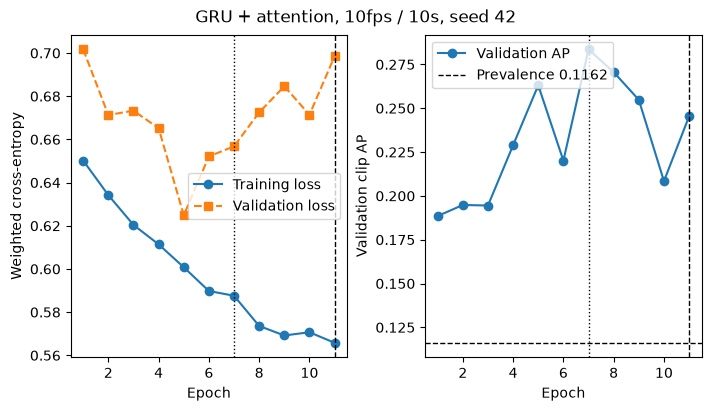

In [75]:
log_text = (PATHS.root / f"logs/expreiments_{m}_{f}fps.log").read_text()

run_end = f"Finished {m}: window {w}s, dropped features [], seed {SEED}"
assert run_end in log_text

run_log = log_text.split(run_end, 1)[0].rsplit("Finished", 1)[-1]

rows = []
for line in run_log.splitlines():
    if not line.startswith("Epoch "):
        continue

    values = {}
    for part in line.split(" | ")[1:]:
        name, number = part.split(": ")
        values[name] = float(number)

    rows.append([values["train loss"], values["validation loss"], values["validation AP"]])

epochs = pd.DataFrame(rows, columns=["train loss", "validation loss", "validation AP"])
epochs.index = pd.RangeIndex(1, len(epochs) + 1, name="epoch")

best_epoch = epochs["validation AP"].idxmax()
best_ap = epochs["validation AP"].max()

last_epoch = len(epochs)

print(
    f"best epoch {best_epoch} (stored {DELIVERABLE.best_epoch}), "
    f"val AP {best_ap:.4f} (stored {DELIVERABLE.val_clip_ap:.4f}); "
    f"stopped after epoch {last_epoch} (stored {DELIVERABLE.epochs_run})"
)

fig, axes = plt.subplots(1, 2, figsize=(7, 4), layout="constrained")
loss_ax = axes[0]
ap_ax = axes[1]

loss_ax.plot(
    epochs.index, epochs["train loss"], marker="o", label="Training loss"
)

loss_ax.plot(
    epochs.index,
    epochs["validation loss"],
    marker="s",
    linestyle="--",
    label="Validation loss",
)
loss_ax.set_ylabel("Weighted cross-entropy")

ap_ax.plot(epochs.index, epochs["validation AP"], marker="o", label="Validation AP")
ap_ax.axhline(
    chance_ap, linestyle="--", color="k", linewidth=1, label=f"Prevalence {chance_ap:.4f}"
)
ap_ax.set_ylabel("Validation clip AP")

for ax in axes:
    ax.axvline(best_epoch, linestyle=":", color="k", linewidth=1)
    ax.axvline(last_epoch, linestyle="--", color="k", linewidth=1)
    ax.set_xlabel("Epoch")

loss_ax.legend(loc="center right")
ap_ax.legend(loc="upper left")

fig.suptitle(f"{MODEL_NAMES[m]}, {f}fps / {w}s, seed {SEED}")

plt.show()


## Appendix: full validation and selection records
All 24 configurations. AP is reported as mean ± sample SD across eight seeds on the fixed validation split. Selection p-values are unadjusted.

In [76]:
shortlist.sort_values("val_ap", ascending=False).round(4)

val_ap      sd  params  \
model              fps window_seconds                           
gru_uni_attention  30  10              0.2894  0.0131  650403   
lstm_uni_attention 15  10              0.2847  0.0082  248611   
                   10  10              0.2831  0.0083  213951   
                   30  10              0.2807  0.0064  191951   
gru_uni_attention  10  10              0.2761  0.0157  115083   
                       5               0.2751  0.0184  119415   
                   15  5               0.2738  0.0208  121611   
                       10              0.2723  0.0331  650403   
                   30  5               0.2703  0.0225  121611   
lstm_uni_attention 30  5               0.2601  0.0199  139647   
                   10  5               0.2549  0.0159   28143   
                   15  5               0.2484  0.0109   28143   
gru                10  5               0.2309  0.0229   85407   
lstm               10  5               0.2242  0.0077  394876   
gru                15  10              0.2197  0.0225   10015   
                   30  5               0.2190  0.0144   60658   
lstm               10  10              0.2184  0.0087  179762   
                   15  5               0.2183  0.0157  458184   
gru                10  10              0.2180  0.0169    8738   
                   15  5               0.2178  0.0129   35487   
                   30  10              0.2149  0.0172    6322   
lstm               30  10              0.2123  0.0143   23102   
                   15  10              0.2123  0.0102   23102   
                   30  5               0.2079  0.0180  394876   

                                       diff_vs_largest  p_vs_largest  \
model              fps window_seconds                                  
gru_uni_attention  30  10                       0.0000           NaN   
lstm_uni_attention 15  10                      -0.0047        0.2500   
                   10  10                      -0.0063        0.2500   
                   30  10                      -0.0087        0.0781   
gru_uni_attention  10  10                      -0.0133        0.0781   
                       5                       -0.0143        0.1484   
                   15  5                       -0.0156        0.1953   
                       10                      -0.0171        0.3125   
                   30  5                       -0.0191        0.0547   
lstm_uni_attention 30  5                       -0.0293        0.0078   
                   10  5                       -0.0345        0.0078   
                   15  5                       -0.0410        0.0078   
gru                10  5                       -0.0585        0.0078   
lstm               10  5                       -0.0652        0.0078   
gru                15  10                      -0.0697        0.0078   
                   30  5                       -0.0704        0.0078   
lstm               10  10                      -0.0710        0.0078   
                   15  5                       -0.0711        0.0078   
gru                10  10                      -0.0714        0.0078   
                   15  5                       -0.0716        0.0078   
                   30  10                      -0.0745        0.0078   
lstm               30  10                      -0.0771        0.0078   
                   15  10                      -0.0771        0.0078   
                   30  5                       -0.0815        0.0078   

                                       eligible  retained  
model              fps window_seconds                      
gru_uni_attention  30  10                  True     False  
lstm_uni_attention 15  10                  True     False  
                   10  10                  True     False  
                   30  10                  True     False  
gru_uni_attention  10  10                  True      True  
                       5                   True     Fal

### Supplementary architecture and temporal contrasts

All 40 paired comparisons are retained: 12 attention vs plain, 12 window length and 16 frame rate contrasts.
The p-values are exploratory, unadjusted, two-sided Wilcoxon signed-rank tests on eight seed pairs.
They reuse the validation data involved in tuning and selection.

In [81]:
pairs = {}

for mdl in ("gru", "lstm"):
    for rate in FPS_OPTIONS:
        for win in (10, 5):
            label = f"{mdl}_uni_attention vs {mdl}, {rate}fps / {win}s"
            with_attention = (f"{mdl}_uni_attention", rate, win)
            plain = (mdl, rate, win)
            pairs[("attention vs plain", label)] = (with_attention, plain)

for label, a, b in window_pairs:
    pairs[("10s vs 5s", label)] = (a, b)

for mdl in MODELS:
    for win in (10, 5):
        for rate in (15, 30):
            label = f"{mdl} {rate} vs 10fps, {win}s"
            pairs[("fps vs 10fps", label)] = ((mdl, rate, win), (mdl, 10, win))

diff_cols = {}

for key in pairs:
    first, second = pairs[key]
    diff_cols[key] = scores[first] - scores[second]

differences = pd.DataFrame(diff_cols)
differences.columns.names = ["family", "comparison"]

p_values = []
for key in differences:
    p_values.append(wilcoxon(differences[key]).pvalue)

contrasts = pd.DataFrame(
    {
        "mean_diff": differences.mean(),
        "wins_of_8": (differences > 0).sum(),
        "losses_of_8": (differences < 0).sum(),
        "p": p_values,
    }
)

contrasts.round(4)

mean_diff  \
family             comparison                                           
attention vs plain gru_uni_attention vs gru, 10fps / 10s       0.0581   
                   gru_uni_attention vs gru, 10fps / 5s        0.0442   
                   gru_uni_attention vs gru, 15fps / 10s       0.0526   
                   gru_uni_attention vs gru, 15fps / 5s        0.0560   
                   gru_uni_attention vs gru, 30fps / 10s       0.0745   
                   gru_uni_attention vs gru, 30fps / 5s        0.0513   
                   lstm_uni_attention vs lstm, 10fps / 10s     0.0647   
                   lstm_uni_attention vs lstm, 10fps / 5s      0.0307   
                   lstm_uni_attention vs lstm, 15fps / 10s     0.0724   
                   lstm_uni_attention vs lstm, 15fps / 5s      0.0301   
                   lstm_uni_attention vs lstm, 30fps / 10s     0.0684   
                   lstm_uni_attention vs lstm, 30fps / 5s      0.0522   
10s vs 5s          GRU, 10 fps                                -0.0129   
                   GRU, 15 fps                                 0.0019   
                   GRU, 30 fps                                -0.0041   
                   LSTM, 10 fps                               -0.0058   
                   LSTM, 15 fps                               -0.0060   
                   LSTM, 30 fps                                0.0044   
                   GRU + attention, 10 fps                     0.0010   
                   GRU + attention, 15 fps                    -0.0015   
                   GRU + attention, 30 fps                     0.0191   
                   LSTM + attention, 10 fps                    0.0282   
                   LSTM + attention, 15 fps                    0.0362   
                   LSTM + attention, 30 fps                    0.0207   
fps vs 10fps       gru 15 vs 10fps, 10s                        0.0017   
                   gru 30 vs 10fps, 10s                       -0.0031   
                   gru 15 vs 10fps, 5s                        -0.0130   
                   gru 30 vs 10fps, 5s                        -0.0119   
                   lstm 15 vs 10fps, 10s                      -0.0061   
                   lstm 30 vs 10fps, 10s                      -0.0061   
                   lstm 15 vs 10fps, 5s                       -0.0059   
                   lstm 30 vs 10fps, 5s                       -0.0163   
                   gru_uni_attention 15 vs 10fps, 10s         -0.0038   
                   gru_uni_attention 30 vs 10fps, 10s          0.0133   
                   gru_uni_attention 15 vs 10fps, 5s          -0.0012   
                   gru_uni_attention 30 vs 10fps, 5s          -0.0048   
                   lstm_uni_attention 15 vs 10fps, 10s         0.0016   
                   lstm_uni_attention 30 vs 10fps, 10s        -0.0023   
                   lstm_uni_attention 15 vs 10fps, 5s         -0.0065   
                   lstm_uni_attention 30 vs 10fps, 5s          0.0052   

                                                            wins_of_8  \
family             comparison                                           
attention vs plain gru_uni_attention vs gru, 10fps / 10s            8   
                   gru_uni_attention vs gru, 10fps / 5s             7   
                   gru_uni_attention vs gru, 15fps / 10s            7   
                   gru_uni_attention vs gru, 15fps / 5s             8   
                   gru_uni_attention vs gru, 30fps / 10s            8   
                   gru_uni_attention vs gru, 30fps / 5s             8   
                   lstm_uni_attention vs lstm, 10fps / 10s          8   
                   lstm_uni_attention vs lstm, 10fps / 5s           8   
                   lstm_uni_attention vs lstm, 15fps / 10s          8   
                   lstm_uni_attention vs lstm, 15fps / 5s           8   
                   lstm_uni_attention vs lstm, 30fps / 10s          8   
                   lstm_uni_attention vs lst